# Детекция автоматизированного сбора данных по суточному окну событий

Для каждой `cookie_id` из `test.csv` модель выдаёт `score` от 0 до 1 - вероятность того, что это трафик сервиса автоматизированного сбора данных. Метрика - Precision при Recall ≥ 0.7, считается официальным `metric.py`.

**Запуск:** рядом с ноутбуком должны лежать `metric.py` и папка `data/` с `train.csv`, `test.csv`, `events.csv.gz`, `sample_submission.csv`. Дальше *Run All*, на выходе `submission.csv`. Версии библиотек - в `requirements.txt`. Все модели с фиксированными `random_state`.

## 1. Подход к решению

**Идея.** Сигнал есть на двух уровнях. Первый - поведение самой куки: сервис сбора данных работает быстрее и ровнее человека, обходит много объявлений и регионов, почти не пользуется избранным, а курсор ставит в одно место или не присылает вовсе. Второй - связи между куками: сервис обходит общий пул объявлений множеством кук, и среди других зрителей объявлений бота ~43% - тоже боты (у людей ~9%).

**Обработка событий.** Берутся только события внутри окна `window_start_ts <= event_ts < window_end_ts`. События после окна есть только в train, на них приходится 42% событий ботов и вся капча, но в момент прогноза они недоступны. Удаляются полные дубликаты, `platform` приводится к трём значениям, события сортируются по времени. Пропуски не заполняются: они структурные, и отсутствие данных само является признаком.

**Признаки (30).** Тайминги (13), охват контента (7), курсор (4), состав действий (3), клиент (1) и связи между куками (2): доля объявлений, которые больше никто не смотрел, и доля объявлений, которые уже смотрел известный бот из прошлых дней. Последний признак строится только по меткам прошлых дней и на валидации пересчитывается внутри каждого фолда.

**Валидация.** Тест лежит позже трейна, поэтому валидация по времени: expanding window, 4 блока по 2 дня, обучение только на прошлом. Отдельно - недельная проверка, которая воспроизводит устаревание меток, как в тесте.

**Модели.** Бейзлайны: RF из quickstart и логистическая регрессия на тех же признаках. Финальная модель - `HistGradientBoostingClassifier`.

**Результат:** P@R≥0.7 = 0.869 на валидации, 0.852 на недельной проверке (quickstart - 0.095).

In [154]:
import os
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.compose import make_column_selector, make_column_transformer
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from metric import precision_at_recall

warnings.filterwarnings("ignore", category=RuntimeWarning)
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)

TIME_COLS = ["cookie_created_at", "window_start_ts", "window_end_ts"]


## 2. Данные и их проблемы

In [155]:
train=pd.read_csv('data/train.csv',parse_dates=TIME_COLS)
test=pd.read_csv('data/test.csv',parse_dates=TIME_COLS)
events=pd.read_csv('data/events.csv.gz',parse_dates=['event_ts'])

print(f'train:{train.shape} test:{test.shape} events:{events.shape}')
print(f'Доля ботов в train: {round(train.target.mean(),3)}')
print(f'Окна train: {train.window_start_ts.min().date()} - {train.window_start_ts.max().date()}')
print(f'Окна test: {test.window_start_ts.min().date()} - {test.window_start_ts.max().date()}')
print(f'Пересечения cookie_id в test и train: {len(set(train.cookie_id) & set(test.cookie_id))} пересечений')
print(f'Значения platform: {events.platform.value_counts().to_dict()}')
print(f'Монотонно ли увеличивается время: {events.event_ts.is_monotonic_increasing}')
print("Доля соседних строк, идущих по возрастанию времени:",
      round((events.event_ts.values[1:] >= events.event_ts.values[:-1]).mean(), 3))
print(f'Доля кук у которых время идет по порядку: {round((events.groupby("cookie_id").event_ts.apply(lambda x: x.is_monotonic_increasing)).mean(),3)}')
print(f'Кол-во дубликатов строк в events: {sum(events.duplicated())}')
print(f'Доля пропусков по колонкам: {events.isna().mean().round(3).to_dict()}')

train:(11091, 5) test:(4909, 4) events:(328905, 14)
Доля ботов в train: 0.081
Окна train: 2026-04-06 - 2026-04-19
Окна test: 2026-04-20 - 2026-04-26
Пересечения cookie_id в test и train: 0 пересечений
Значения platform: {'desktop': 46866, 'WEB': 46476, 'Web': 46365, 'web': 45951, 'ANDROID': 42462, 'Android': 42254, 'android': 42159, 'iphone': 4103, 'IOS': 4100, 'iOS': 4091, 'ios': 4078}
Монотонно ли увеличивается время: False
Доля соседних строк, идущих по возрастанию времени: 0.5
Доля кук у которых время идет по порядку: 0.035
Кол-во дубликатов строк в events: 4863
Доля пропусков по колонкам: {'cookie_id': 0.0, 'event_ts': 0.0, 'eid': 0.0, 'event_name': 0.0, 'platform': 0.0, 'user_agent': 0.0, 'item_id': 0.348, 'item_category': 0.1, 'item_location': 0.072, 'seller_type': 0.407, 'search_query': 0.695, 'search_page': 0.695, 'pointer_x': 0.67, 'pointer_y': 0.67}


In [156]:
platform = events.platform.str.lower().replace({"desktop": "web", "iphone": "ios"}) #курсор по платформам
print(events.pointer_x.notna().groupby(platform).mean().round(2))
cols = ["item_id", "item_category", "item_location", "seller_type", "search_query", "search_page", "pointer_x"]
events.groupby("event_name")[cols].apply(lambda d: d.notna().mean()).round(2) #доля значений заполненная у каждого типа событий

platform
android    0.00
ios        0.00
web        0.58
Name: pointer_x, dtype: float64


,item_id,item_category,item_location,seller_type,search_query,search_page,pointer_x
event_name,,,,,,,
captcha_shown,0.0,0.00,0.00,0.00,0.0,0.0,0.27
contact_chat_open,1.0,0.94,0.97,0.92,0.0,0.0,0.31
contact_message_sent,1.0,0.94,0.97,0.91,0.0,0.0,0.32
contact_phone_show,1.0,0.94,0.97,0.91,0.0,0.0,0.32
favorite_add,1.0,0.94,0.97,0.91,0.0,0.0,0.35
item_view,1.0,0.94,0.97,0.91,0.0,0.0,0.33
login,0.0,0.00,0.00,0.00,0.0,0.0,0.35
photo_swipe,1.0,0.94,0.97,0.91,0.0,0.0,0.34
search_results_view,0.0,0.94,0.97,0.00,1.0,1.0,0.33


- Тест целиком лежит **позже** трейна (20–26 апреля против 6–19 апреля), куки не пересекаются. Значит, валидировать нужно по времени.
- `platform` записан в 11 вариантах регистра и синонимов, а по смыслу значений три: web, android, ios.
- ~4.9 тыс. полных дубликатов строк.
- Строки **не отсортированы** по времени. Паузы между событиями нельзя считать без сортировки.
- Пропуски в основном структурные: поля заполняются только там, где имеют смысл. search_query и search_page есть только у просмотра выдачи, item_id и seller_type - только у событий с объявлением, login и капча не заполнены вовсе. Курсор есть только на web, и то не у всех событий (58%), в приложении его нет совсем. Кроме того, есть небольшие случайные пропуски: категория не указана у 6% событий, локация у 3%.

Поэтому пропуски не будут заполняться: отсутствие значения тоже информация. Признаки считаются только по заполненным значениям, а если данных нет совсем (например, курсора у приложения), признак остаётся NaN.

## 3. Окно наблюдения и утечка

In [157]:
meta=pd.concat([train.assign(part="train"), test.assign(target=np.nan,part="test")],ignore_index=True)
e = events.merge(meta, on="cookie_id", how="left")
print('У каждого события есть куки если 0: ', e.part.isna().sum())
e["position"]=np.select([e.event_ts < e.window_start_ts, e.event_ts >= e.window_end_ts], ["before", "after"], "inside")
print(f'Положение события относительно окна:\n{pd.crosstab(e.position, e.part)}')
print(f'Доля событий после окна по классам(для train):\n{e[e.part == "train"].groupby("target").position.apply(lambda x: (x == "after").mean()).round(3).to_string()}')
cap=e[e.eid == 900]
print(f'Капча по положению и классу:\n {pd.crosstab(cap.position, [cap.part,cap.target])}')

У каждого события есть куки если 0:  0
Положение события относительно окна:
part       test   train
position               
after         0   40779
inside    89690  198436
Доля событий после окна по классам(для train):
target
0.0    0.110
1.0    0.425
Капча по положению и классу:
 part     train      
target     0.0   1.0
position            
after      958  6970


В train есть события *после* конца окна, у ботов это 42% всех событий. **Все** показы капчи лежат после окна, 88% из них — у ботов. В test событий вне окна нет вообще.

Признаки по этим событиям недоступны в момент окончания окна. Если их не отрезать, модель выучит правило «после окна были события или капча → бот» и провалит тест. Поэтому дальше используются только события с `window_start_ts <= event_ts < window_end_ts`.

## 4. Очистка событий

In [158]:
inside = e[(e.position == "inside") & (e.part == "train")].copy()   # события train внутри окна
inside["dup"] = inside.duplicated()    # True, если строка — повтор уже встреченной
print(f'Доля дублей у людей и у ботов:\n{inside.groupby("target").dup.mean().round(4).to_string()}')

Доля дублей у людей и у ботов:
target
0.0    0.0148
1.0    0.0152


Доля дублей у классов одинаковая, значит, дубли это артефакт логирования, а не поведение ботов, их можно удалить.

In [159]:
PLATFORM_MAP = {"desktop": "web", "web": "web", "android": "android", "ios": "ios", "iphone": "ios"}

def clean_events(events, meta):
    # 1) только события внутри окна своей куки: события после окна есть только в train — утечка
    ev = events.merge(meta[["cookie_id", "window_start_ts", "window_end_ts"]], on="cookie_id")
    ev = ev[(ev.event_ts >= ev.window_start_ts) & (ev.event_ts < ev.window_end_ts)]
    ev = ev.drop(columns=["window_start_ts", "window_end_ts"])
    # 2) полные дубликаты — артефакт логирования (их доля одинакова у ботов и людей)
    ev = ev.drop_duplicates()
    # 3) platform записан в 11 вариантах, по смыслу их 3
    ev["platform"] = ev.platform.str.lower().map(PLATFORM_MAP).fillna("other")
    # 4) строки в файле перемешаны, а паузы между событиями считаются по порядку
    return ev.sort_values(["cookie_id", "event_ts"], kind="mergesort").reset_index(drop=True)

meta_all=pd.concat([train.drop(columns="target"),test], ignore_index=True)
ev=clean_events(events, meta_all)

print(f'platform: {ev.platform.value_counts().to_dict()}')
print(f'Событий после очистки: {len(ev)}\nКук без событий в окне: {(~meta_all.cookie_id.isin(ev.cookie_id)).sum()}')
print(f'Отсортировано по времени внутри кук: {ev.groupby("cookie_id").event_ts.is_monotonic_increasing.all()}')


platform: {'web': 158898, 'android': 110556, 'ios': 14379}
Событий после очистки: 283833
Кук без событий в окне: 0
Отсортировано по времени внутри кук: True


## 5. Чем боты отличаются от людей

In [160]:
def ua_family(ua: str) -> str:
    # Грубое семейство клиента, оставляем только тип клиента.
    if ua.startswith("Avito/"):
        return "app"
    if "HeadlessChrome" in ua:
        return "headless"
    if not ua.startswith("Mozilla"):
        return "http_lib"          # curl, python-requests, Scrapy, Go-http-client, node-fetch
    if "YaBrowser" in ua:
        return "yabrowser"
    if "Firefox" in ua:
        return "firefox"
    if "iPhone" in ua or "Android" in ua:
        return "mobile_web"
    return "chrome_safari"


family = ev.user_agent.map(ua_family).groupby(ev.cookie_id).apply(lambda s: s.mode().iloc[0])
d = train.set_index("cookie_id").join(family.rename("ua_family"))
ua_tab = pd.crosstab(d.ua_family, d.target)
ua_tab["доля ботов"] = (ua_tab[1.0] / ua_tab.sum(axis=1)).round(3)
ua_tab

target,0,1,доля ботов
ua_family,,,
app,1944,197,0.092
chrome_safari,2585,250,0.088
firefox,1294,121,0.086
headless,211,75,0.262
http_lib,156,44,0.220
mobile_web,2919,114,0.038
yabrowser,1083,98,0.083


**User-Agent как есть не работает.** Куки со «скриптовыми» UA (`curl`, `python-requests`, `Scrapy`…) в ~80% случаев размечены как люди. Правило «не браузер → бот» дало бы много ложных срабатываний. В модель идёт только грубое семейство клиента, как один из признаков.

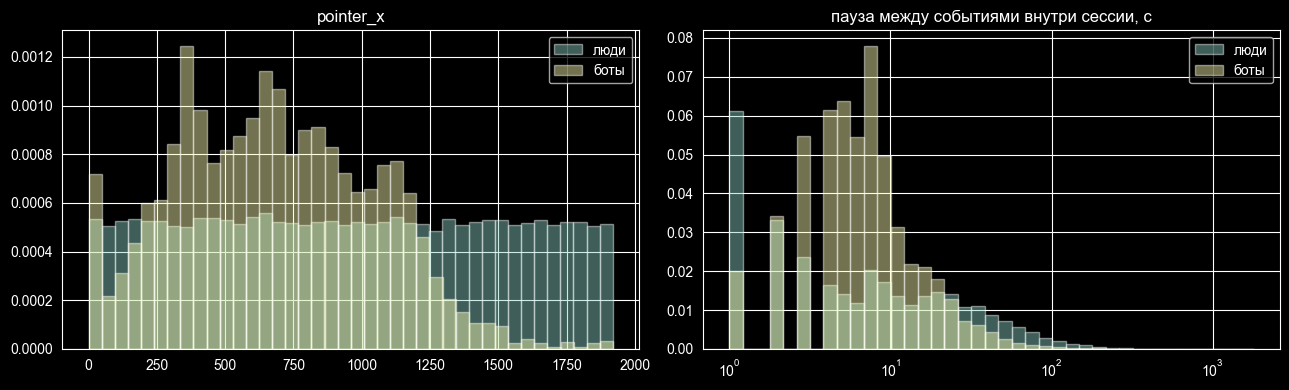

In [161]:
ev_labeled = ev.merge(train[["cookie_id", "target"]], on="cookie_id")
ev_labeled["dt"] = ev_labeled.groupby("cookie_id").event_ts.diff().dt.total_seconds()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
p = ev_labeled[ev_labeled.pointer_x.notna()]
for t, name in [(0, "люди"), (1, "боты")]:
    axes[0].hist(p[p.target == t].pointer_x, bins=40, density=True, alpha=0.45, label=name)
axes[0].set_title("pointer_x")
axes[0].legend()

s = ev_labeled[(ev_labeled.dt > 0) & (ev_labeled.dt <= 1800)]
bins = np.logspace(0, np.log10(1800), 40)
for t, name in [(0, "люди"), (1, "боты")]:
    axes[1].hist(s[s.target == t].dt, bins=bins, density=True, alpha=0.45, label=name)
axes[1].set_xscale("log")
axes[1].set_title("пауза между событиями внутри сессии, с")
axes[1].legend()
plt.tight_layout()

In [162]:
g = ev_labeled.groupby("cookie_id")
agg_df = pd.DataFrame({
    "target": g.target.first(),
    "уникальных локаций": g.item_location.nunique(),
    "уникальных категорий": g.item_category.nunique(),
    "средняя страница выдачи": g.search_page.mean(),
    "доля поиска": g.eid.apply(lambda x: (x == 100).mean()),
    "доля favorite_add": g.eid.apply(lambda x: (x == 400).mean()),
    "медиана паузы, с": g.dt.median(),
})
agg_df.groupby("target").mean().T.round(3).rename(columns={0: "люди", 1: "боты"})

target,люди,боты
уникальных локаций,5.882,9.790
уникальных категорий,2.281,1.788
средняя страница выдачи,2.316,3.587
доля поиска,0.308,0.331
доля favorite_add,0.069,0.033
"медиана паузы, с",226.310,101.188


In [163]:
# связи между куками: сколько кук смотрели объявление и какая доля ДРУГИХ зрителей — боты (только train)
lv = ev_labeled[ev_labeled.item_id.notna()][["cookie_id", "item_id", "target"]].drop_duplicates()
per_item = lv.groupby("item_id").target.agg(["sum", "size"])
lv = lv.join(per_item, on="item_id")
lv["other_bot_share"] = (lv["sum"] - lv.target) / (lv["size"] - 1).replace(0, np.nan)
lv.groupby("target")[["size", "other_bot_share"]].mean().round(3) \
  .rename(index={0: "люди", 1: "боты"}, columns={"size": "зрителей объявления", "other_bot_share": "доля ботов среди других зрителей"})

,зрителей объявления,доля ботов среди других зрителей
target,,
люди,2.894,0.088
боты,4.559,0.431


**Что видно:**
- **Курсор.** У людей координаты почти равномерно покрывают экран, у ботов скучены у центра. Самый сильный сигнал, но только для web.
- **Темп.** Внутри сессий паузы у ботов в основном 3–30 с, у людей 30–300 с.
- **Охват.** Боты смотрят больше локаций, но меньше категорий и глубже листают выдачу.
- **Состав действий.** Боты чаще ищут и вдвое реже добавляют в избранное.
- **Связи между куками.** Среди других зрителей объявлений бота ~43% — тоже боты, у людей ~9%.

## 6. Валидация по времени

Тест лежит позже трейна, поэтому валидация тоже по времени: модель обучается только на прошлом и проверяется на будущем. Схема expanding window: последние 8 дней train делятся на 4 блока по 2 дня, и для каждого блока модель обучается на всех окнах, начавшихся раньше него.

In [164]:
VALID_BLOCKS = [("2026-04-12", "2026-04-14"), ("2026-04-14", "2026-04-16"),
                ("2026-04-16", "2026-04-18"), ("2026-04-18", "2026-04-20")]
ws = train.window_start_ts
y = train.target.to_numpy()

def time_folds(window_start):
    for start, end in VALID_BLOCKS:
        tr_idx = np.where(window_start<start)[0]
        va_idx = np.where((start <= window_start) & (window_start < end))[0]
        yield tr_idx, va_idx

def evaluate(make_model, X):
    oof = np.full(len(y), np.nan)
    per_block = []
    for tr_idx, va_idx in time_folds(ws):
        model = make_model()
        model.fit(X.iloc[tr_idx], y[tr_idx])
        oof[va_idx] = model.predict_proba(X.iloc[va_idx])[:,1]
        per_block.append(precision_at_recall(y[va_idx], oof[va_idx]))
    m = ~np.isnan(oof)
    return {"P@R0.7 pooled": precision_at_recall(y[m],oof[m]), "PR-AUC": average_precision_score(y[m],oof[m]), "ROC-AUC": roc_auc_score(y[m],oof[m]), "blocks": per_block}

In [165]:
feature_df = pd.DataFrame({"n_events": ev.groupby("cookie_id").size(),
                  "item_nunique": ev.groupby("cookie_id").item_id.nunique()})
Xq = feature_df.loc[train.cookie_id].reset_index(drop=True)

for i, (tr_idx, va_idx) in enumerate(time_folds(ws)):
    print(f"блок {i}: train {len(tr_idx)}, valid {len(va_idx)}, ботов {int(y[va_idx].sum())}")

evaluate(lambda: RandomForestClassifier(300, min_samples_leaf=3, random_state=0, n_jobs=-1), Xq)

блок 0: train 5113, valid 1660, ботов 120
блок 1: train 6773, valid 1627, ботов 135
блок 2: train 8400, valid 1453, ботов 126
блок 3: train 9853, valid 1238, ботов 94


{'P@R0.7 pooled': 0.09479606188466948,
 'PR-AUC': 0.20500457925625754,
 'ROC-AUC': 0.6094585728358693,
 'blocks': [0.08700102354145343,
  0.10770975056689343,
  0.08840864440078586,
  0.10138248847926268]}

- Выбран не случайный сплит. Тест лежит позже трейна. При случайном сплите модель училась бы на более поздних днях и проверялась на более ранних, а оценка была бы завышенной.
- Оценка pooled. В одном блоке всего 94–135 ботов, и одна-две ошибки заметно двигают метрику. На всех блоках вместе ~475 ботов, это надёжнее.
- quickstart даёт 0.095 при доле ботов 0.081, то есть почти уровень константы. Объём активности сам по себе ботов не выдаёт.

In [166]:
HGB_PARAMS = dict(learning_rate=0.03, max_iter=600, max_leaf_nodes=15, min_samples_leaf=50,
                  l2_regularization=5.0, max_features=0.5, categorical_features="from_dtype")

def make_hgb(seed=42):
    return HistGradientBoostingClassifier(**HGB_PARAMS, random_state=seed)

## 7. Признаки

Одна строка на куку, всё считается по очищенным событиям внутри окна. Каждая группа признаков проверяет гипотезу из раздела 5. После каждой группы модель прогоняется через валидацию, чтобы видеть её вклад.

Пропуски не заполняются: если у куки нет нужных событий (например, курсора в приложении или поиска), признак остаётся `NaN`, и бустинг обрабатывает это как отдельное значение «данных нет». Единственный категориальный признак `ua_family` передаётся бустингу как `category`.

### 7.1. Тайминги (13 признаков)

Гипотеза: скрипт работает быстрее человека и с однотипными паузами.

- `dt` - пауза до предыдущего события той же куки.
- Сессия - непрерывный заход на сайт. Пауза больше 30 минут означает новый заход. Длинные перерывы не описывают темп работы и размывают статистики, поэтому признаки `sdt_*` считаются только по паузам внутри сессий.
- `dt_entropy` - энтропия распределения пауз по логарифмическим «ящикам» (1-2 с, 2-4 с, …). Низкая, если паузы однотипные, как у скрипта с `sleep`.
- `item_dwell_median` - «время на странице»: пауза после просмотра объявления до следующего действия.

In [167]:
SESSION_GAP_S = 30 * 60  # пауза длиннее 30 минут - новая сессия


def timing_features(ev):
    d = pd.DataFrame({"cookie_id": ev.cookie_id,
                      "dt": ev.groupby("cookie_id").event_ts.diff().dt.total_seconds()})
    gd = d.groupby("cookie_id").dt
    f = pd.DataFrame({
        "dt_min": gd.min(),  # минимальная пауза
        "dt_std": gd.std(),  # разброс пауз
        "dt_share_le10": gd.apply(lambda s: (s <= 10).mean()),  # доля пауз <= 10 с
        "active_time_s": d.dt.where(d.dt <= SESSION_GAP_S, 0).groupby(d.cookie_id).sum()
        # сумма пауз, которые <= SESSION_GAP_S
    })
    g = ev.groupby("cookie_id")
    f["duration_s"] = (g.event_ts.max() - g.event_ts.min()).dt.total_seconds()  # last - first событие
    s = d[(d.dt > 0) & (d.dt <= SESSION_GAP_S)].groupby("cookie_id").dt  # только паузы внутри сессий
    f["sdt_p25"] = s.quantile(0.25)  # 25-й процентиль
    f["sdt_median"] = s.median()
    f["sdt_p75"] = s.quantile(0.75)
    f["sdt_iqr_rel"] = (f["sdt_p75"] - f["sdt_p25"]) / f[
        "sdt_median"]  # (p75 − p25) / median - разброс относительно типичной паузы
    f["sdt_share_3_30"] = s.apply(lambda x: x.between(3, 30).mean())  # доля пауз от 3 до 30 с
    f["sdt_log_std"] = s.apply(lambda x: np.log(x).std())  # std логарифма пауз
    logb = np.floor(np.log2(d.dt.clip(lower=1)))  # номер ящика
    counts = (pd.DataFrame({"c": d.cookie_id, "b": logb}).dropna().groupby(
        ["c", "b"]).size())  # сколько пауз у куки в каждом ящике
    f["dt_entropy"] = counts.groupby(level="c").apply(lambda s: -((s / s.sum()) * np.log(s / s.sum())).sum())  # энтропия
    nxt = ev.groupby("cookie_id").event_ts.shift(-1)                   # время следующего события той же куки
    dwell = (nxt - ev.event_ts).dt.total_seconds()
    ok = (ev.eid == 200) & (dwell<= SESSION_GAP_S)
    f["item_dwell_median"] = dwell[ok].groupby(ev.cookie_id[ok]).median()
    return f

In [168]:
tf = timing_features(ev)
print(tf.shape)
print(tf.join(train.set_index("cookie_id").target).groupby("target").median().round(2).T)

feats = pd.DataFrame(index=meta_all.cookie_id).join(tf)
X = feats.loc[train.cookie_id].reset_index(drop=True)
evaluate(make_hgb, X)

(16000, 13)
target                 0.0      1.0
dt_min                7.00     5.00
dt_std             1751.05  1378.39
dt_share_le10         0.07     0.15
active_time_s       706.00   604.00
duration_s         8326.50  9092.00
sdt_p25              26.75    14.00
sdt_median           49.00    22.00
sdt_p75              83.00    34.88
sdt_iqr_rel           1.04     0.71
sdt_share_3_30        0.32     0.64
sdt_log_std           1.06     0.69
dt_entropy            1.58     1.33
item_dwell_median    47.75    22.00


{'P@R0.7 pooled': 0.2893136403127715,
 'PR-AUC': 0.6004899280140482,
 'ROC-AUC': 0.8489526287096991,
 'blocks': [0.28668941979522183,
  0.25333333333333335,
  0.2755417956656347,
  0.3489583333333333]}

Медианные паузы внутри сессий у ботов вдвое короче (22 с против 49 с), на странице объявления они проводят 22 с против 48 с. У ботов 64% пауз укладываются в 3-30 с (у людей 32%), а разброс пауз и энтропия ниже: темп ровнее, как у скрипта.

**Тайминги (13) → P@R 0.289, PR-AUC 0.600.**

### 7.2. Охват контента (7 признаков)

Гипотеза: сервис сбора данных обходит много объявлений и регионов в одной-двух категориях и глубоко листает выдачу, как при мониторинге цен.

In [169]:
def coverage_features(ev):
    g = ev.groupby("cookie_id")
    n = g.size()                                         # событий у куки
    f = pd.DataFrame({
        "item_nunique": g.item_id.nunique(),          # уникальных объявлений
        "category_nunique": g.item_category.nunique(),      # уникальных категорий
        "location_nunique": g.item_location.nunique(),      # уникальных локаций
    })
    f["item_repeat_share"] = 1 - f["item_nunique"]/g.item_id.count().clip(lower=1)      # доля повторных просмотров
    f["location_per_event"] = f["location_nunique"]/n    # уникальных локаций на одно событие
    search = ev[ev.eid == 100].groupby("cookie_id").search_page     # только просмотры выдачи
    f["page_mean"] = search.mean()              # средняя страница выдачи
    f["page_max"] = search.max()               # самая дальняя страница
    return f

In [170]:
cf = coverage_features(ev)
print(cf.join(train.set_index("cookie_id").target).groupby("target").median().round(2).T)

feats = pd.DataFrame(index=meta_all.cookie_id).join(tf).join(cf)
X = feats.loc[train.cookie_id].reset_index(drop=True)
evaluate(make_hgb, X)

target               0.0    1.0
item_nunique        6.00  10.00
category_nunique    2.00   2.00
location_nunique    5.00   8.00
item_repeat_share   0.18   0.19
location_per_event  0.42   0.41
page_mean           2.00   3.19
page_max            4.00   7.00


{'P@R0.7 pooled': 0.45566166439290584,
 'PR-AUC': 0.6786810869079164,
 'ROC-AUC': 0.899156632267567,
 'blocks': [0.5345911949685535,
  0.5523255813953488,
  0.3662551440329218,
  0.4714285714285714]}

Боты смотрят больше объявлений (10 против 6) и локаций (8 против 5), но столько же категорий, и глубже листают выдачу (максимальная страница 7 против 4).

**+ охват (20) → P@R 0.456, PR-AUC 0.679.**

### 7.3. Курсор (4 признака, только web)

Гипотеза из графика в разделе 5: люди водят курсором по всему экрану, боты ставят его примерно в одно место у центра. Координаты нормируются на размер экрана (1920×1080).

- `ptr_present_share` - доля web-событий, где курсор вообще записан. У web-кук без курсора он равен 0, у приложения `NaN` (там курсора не бывает).

In [171]:
SCREEN_W, SCREEN_H = 1920, 1080          # максимумы pointer_x / pointer_y в данных

def pointer_features(ev):
    p = ev[ev.pointer_x.notna()].copy()                        # только события с курсором
    # расстояние от центра экрана в долях экрана: 0 — центр, ~0.7 — угол
    p["center_dist"] = np.hypot(p.pointer_x / SCREEN_W - 0.5, p.pointer_y / SCREEN_H - 0.5)
    gp = p.groupby("cookie_id")
    f = pd.DataFrame({
        "ptr_x_std": gp["pointer_x"].std()/SCREEN_W,              # std(pointer_x), делённый на ширину экрана
        "ptr_y_std": gp["pointer_y"].std()/SCREEN_H,              # std(pointer_y), делённый на высоту
        "ptr_center_dist_max": gp["center_dist"].max(),    # насколько далеко от центра курсор уходил хотя бы раз
    })
    web = ev.platform == "web"
    present = ev.pointer_x.notna()[web].groupby(ev.cookie_id[web]).mean().rename("ptr_present_share")
    return f.join(present, how="outer")

In [172]:
pf = pointer_features(ev)
print(pf.join(train.set_index("cookie_id").target).groupby("target").median().round(2).T)

feats = pd.DataFrame(index=meta_all.cookie_id).join(tf).join(cf).join(pf)
X = feats.loc[train.cookie_id].reset_index(drop=True)
evaluate(make_hgb, X)

target                0.0   1.0
ptr_x_std            0.29  0.11
ptr_y_std            0.29  0.19
ptr_center_dist_max  0.59  0.53
ptr_present_share    0.93  0.00


{'P@R0.7 pooled': 0.6478599221789884,
 'PR-AUC': 0.7528884338147286,
 'ROC-AUC': 0.92934781984946,
 'blocks': [0.717948717948718,
  0.6834532374100719,
  0.6267605633802817,
  0.6407766990291263]}

Разброс курсора по горизонтали у ботов втрое меньше (0.11 против 0.29 ширины экрана). Ещё сильнее отличается сам факт наличия курсора: у людей на web он записан в 93% событий, а у большинства web-ботов не записан ни разу (медиана 0). Отсутствие данных здесь само по себе признак.

**+ курсор (24) → P@R 0.648, PR-AUC 0.753.**

### 7.4. Состав действий (3 признака) и клиент (1 признак)

- Состав действий: доля поисков, доля добавлений в избранное и число контактов на один просмотр объявления.
- Клиент: самое частое семейство User-Agent у куки (раздел 5).

In [173]:
CONTACT_EIDS = [300, 301, 303]    # показ телефона, открытие чата, отправка сообщения

def composition_features(ev):
    g = ev.groupby("cookie_id").eid
    return pd.DataFrame({
        "share_search": g.apply(lambda x: (x==100).mean()),        # доля событий с eid == 100
        "share_fav": g.apply(lambda x: (x==400).mean()),           # доля событий с eid == 400
        "contact_per_item": g.apply(lambda x: x.isin(CONTACT_EIDS).sum() / max((x == 200).sum(), 1)),    # число событий из CONTACT_EIDS / число eid == 200
    })


def client_features(ev):
    family = ev.user_agent.map(ua_family).groupby(ev.cookie_id).apply(lambda s: s.mode().iloc[0])
    return family.astype("category").rename("ua_family").to_frame()

In [174]:
comp = composition_features(ev)
print(comp.join(train.set_index("cookie_id").target).groupby("target").mean().round(3).T)

feats = pd.DataFrame(index=meta_all.cookie_id).join(tf).join(cf).join(pf).join(comp)
X = feats.loc[train.cookie_id].reset_index(drop=True)
print(evaluate(make_hgb, X))

feats = feats.join(client_features(ev))
X = feats.loc[train.cookie_id].reset_index(drop=True)
evaluate(make_hgb, X)

target              0.0    1.0
share_search      0.308  0.331
share_fav         0.069  0.033
contact_per_item  0.189  0.196
{'P@R0.7 pooled': 0.7061310782241015, 'PR-AUC': 0.7683176313951411, 'ROC-AUC': 0.9319944145298735, 'blocks': [0.7567567567567568, 0.7364341085271318, 0.6267605633802817, 0.6633663366336634]}


{'P@R0.7 pooled': 0.6795918367346939,
 'PR-AUC': 0.7732340590231713,
 'ROC-AUC': 0.9302617710913665,
 'blocks': [0.7636363636363637,
  0.7142857142857143,
  0.6275862068965518,
  0.7010309278350515]}

Боты чаще ищут (0.33 против 0.31) и вдвое реже добавляют в избранное (0.033 против 0.069). Контактов на просмотр объявления в среднем столько же, но у сборщиков контактов это отношение распределено иначе, и бустинг может это использовать.

**+ состав действий (27) → P@R 0.706, PR-AUC 0.768.**
**+ клиент (28) → P@R 0.680, PR-AUC 0.773.**

### 7.5. Связи между куками: популярность объявлений (1 признак)

Гипотеза из раздела 5: сервис обходит общий пул объявлений множеством кук. Среди других зрителей объявлений бота ~43% - тоже боты, у людей ~9%.

`cc_share_pop_0` - доля объявлений куки, которые за последние 7 дней (включая день окна) не смотрела ни одна другая кука. Метки не используются. Будущие дни в окно не попадают (`rolling("7D")` смотрит только назад). Просмотры других кук в тот же день допустимы: все окна - это календарные сутки, поэтому к концу окна куки события этого дня уже произошли.

In [175]:
WINDOW_DAY = meta_all.set_index("cookie_id").window_start_ts
views = ev[ev.item_id.notna()][["cookie_id", "item_id"]].drop_duplicates()
views["day"] = views.cookie_id.map(WINDOW_DAY)

def popularity_feature(views):
    # сколько кук смотрели объявление в каждый день
    n = views.groupby(["item_id", "day"]).size().rename("n").reset_index().sort_values(["item_id", "day"])
    # сумма за 7 дней, заканчивая этим днём, отдельно по каждому объявлению
    n["cum"] = n.groupby("item_id").apply(lambda g: g.set_index("day").n.rolling("7D").sum(),include_groups=False).to_numpy()
    w = views.merge(n[["item_id", "day", "cum"]], on=["item_id", "day"])
    w["others"] = w.cum - 1     # зрителей без самой куки
    return (w.others == 0).groupby(w.cookie_id).mean().rename("cc_share_pop_0")

In [176]:
feats = feats.join(popularity_feature(views))
X = feats.loc[train.cookie_id].reset_index(drop=True)
evaluate(make_hgb, X)

{'P@R0.7 pooled': 0.7672811059907834,
 'PR-AUC': 0.7835631959465925,
 'ROC-AUC': 0.9329596296756792,
 'blocks': [0.75, 0.75, 0.7142857142857143, 0.7419354838709677]}

**+ популярность объявлений (29) → P@R 0.767, PR-AUC 0.784.**

### 7.6. Связи между куками: известные боты среди зрителей (1 признак)

`lb_items_with_bot` - доля объявлений куки, которые уже смотрел **известный бот**, то есть кука с меткой 1 из дней *строго раньше* дня окна текущей куки. Своя метка и метки соседей по тому же дню не участвуют: `merge_asof` ищет известные просмотры только до дня `d − 1`.

In [177]:
def label_feature(views, known):
    # known: cookie_id -> target для кук, чьи метки считаются известными
    lab = views[views.cookie_id.isin(known.index)].copy()
    lab["y"] = lab.cookie_id.map(known)
    # сколько известных ботов смотрели объявление в каждый день -> накопительно по дням
    a = lab.groupby(["item_id", "day"]).y.sum().rename("bots").reset_index().sort_values(["item_id", "day"])
    a["cum_bots"] = a.groupby("item_id").bots.cumsum()

    # для каждого просмотра (кука, объявление, день d) ищем cum_bots на последний день <= d-1
    q = views.assign(query_day=views.day - pd.Timedelta(days=1)).sort_values("query_day")
    m = pd.merge_asof(q, a[["item_id", "day", "cum_bots"]].rename(columns={"day": "known_day"}).sort_values("known_day"),
                      left_on="query_day", right_on="known_day", by="item_id", direction="backward")
    return (m.cum_bots.fillna(0) > 0).groupby(m.cookie_id).mean().rename("lb_items_with_bot")

In [178]:
def evaluate_lb(make_model, feats):
    oof = np.full(len(y), np.nan)
    per_block = []
    for tr_idx, va_idx in time_folds(ws):
        known = train.iloc[tr_idx].set_index("cookie_id").target          # метки только обучающей части
        X = feats.join(label_feature(views, known)).loc[train.cookie_id].reset_index(drop=True)
        model = make_model().fit(X.iloc[tr_idx], y[tr_idx])
        oof[va_idx] = model.predict_proba(X.iloc[va_idx])[:, 1]
        per_block.append(precision_at_recall(y[va_idx], oof[va_idx]))
    m = ~np.isnan(oof)
    return {"P@R0.7 pooled": precision_at_recall(y[m], oof[m]), "PR-AUC": average_precision_score(y[m], oof[m]),
            "ROC-AUC": roc_auc_score(y[m], oof[m]), "blocks": per_block}
evaluate_lb(make_hgb, feats)

{'P@R0.7 pooled': 0.8694516971279374,
 'PR-AUC': 0.8154717692847201,
 'ROC-AUC': 0.9381860611915032,
 'blocks': [0.8673469387755102, 0.8715596330275229, 0.875, 0.8481012658227848]}

**Почему признак пересчитывается в каждом фолде.** Признак зависит от того, какие метки считаются известными. Если посчитать его один раз по всем меткам train, то в фолде 0 кука из 13 апреля получала бы подсказку из меток кук 12 апреля. Но 12 апреля в этом фолде - валидация, эти метки модель знать не должна. Оценка вышла бы завышенной. Поэтому в каждом фолде признак строится только по меткам обучающей части.

**+ известные боты (30) → P@R 0.869, PR-AUC 0.815**, рост во всех четырёх блоках (0.867 / 0.872 / 0.875 / 0.848).

### 7.7. Итог по признакам

| после группы | признаков | P@R0.7 | PR-AUC |
|---|---|---|---|
| quickstart | 2 | 0.095 | 0.205 |
| тайминги | 13 | 0.289 | 0.600 |
| + охват | 20 | 0.456 | 0.679 |
| + курсор | 24 | 0.648 | 0.753 |
| + состав действий | 27 | 0.706 | 0.768 |
| + клиент | 28 | 0.680 | 0.773 |
| + популярность объявлений | 29 | 0.767 | 0.784 |
| + известные боты | 30 | **0.869** | **0.815** |

Поведенческие признаки дают ~0.70. Самые сильные из них - курсор и тайминги. Связи между куками поднимают результат до ~0.87: сервис обходит общий пул объявлений разными куками, и это видно, только если смотреть на куки вместе.

## 8. Бейзлайны и финальная модель

Модели сравниваются на одной и той же валидации:
1. **quickstart RF (2)** - стартовая точка из quickstart: случайный лес на числе событий и числе объявлений.
2. **LogReg (30)** - логистическая регрессия на тех же 30 признаках. Показывает, сколько дают сами признаки без нелинейной модели. Пропуски заполняются медианой с флагом «значение было пропущено», признаки масштабируются, `ua_family` кодируется через one-hot. Всё это внутри пайплайна, поэтому в каждом фолде статистики считаются только по обучающей части.
3. **HGB (30)** - градиентный бустинг на 30 признаках, финальная модель. Пропуски и категориальный признак обрабатывает сам.

In [179]:
def make_logreg():
    prep = make_column_transformer(
        (make_pipeline(SimpleImputer(strategy="median", add_indicator=True), StandardScaler()),
         make_column_selector(dtype_include="number")),                                          # числовые признаки
        (OneHotEncoder(handle_unknown="ignore"), make_column_selector(dtype_include="category")),  # ua_family
    )
    return make_pipeline(prep, LogisticRegression(C=0.1, max_iter=3000))

In [180]:
results = {
    "quickstart RF (2)":   evaluate(lambda: RandomForestClassifier(300, min_samples_leaf=3, random_state=0, n_jobs=-1), Xq),
    "LogReg (30)":         evaluate_lb(make_logreg, feats),
    "HGB (30)":            evaluate_lb(make_hgb, feats),
}
pd.DataFrame(results).T

,P@R0.7 pooled,PR-AUC,ROC-AUC,blocks
quickstart RF (2),0.094796,0.205005,0.609459,"[0.08700102354145343, 0.10770975056689343, 0.0..."
LogReg (30),0.800481,0.775772,0.9343,"[0.8155339805825242, 0.8135593220338984, 0.731..."
HGB (30),0.869452,0.815472,0.938186,"[0.8673469387755102, 0.8715596330275229, 0.875..."


**Выводы:**
- quickstart почти не отличается от константы (0.095 при доле ботов 0.081): объём активности сам по себе ботов не выдаёт.
- **Основной прирост дают признаки:** логрегрессия на 30 признаках поднимает результат с 0.095 до ….
- **Бустинг лучше логрегрессии** (0.869 против 0.800) за счёт нелинейностей. Например, признаки курсора информативны только на web, а у приложения они `NaN`, и дерево учитывает это само.


## 9. Проверка в условиях теста

На основной валидации блоки по 2 дня, поэтому метки для признака на известных ботах устаревают максимум на 1-2 дня. В тесте разрыв больше: он длится неделю (20-26 апреля), и метки известны только до 19 апреля, то есть к концу теста они устаревают до 7 дней.

Чтобы проверить, переносит ли модель такое устаревание, делаем недельную проверку: обучение на 6-12 апреля (метки известны только за эти дни), проверка на 13-19 апреля. Отдельно смотрим первую половину недели (метки свежее) и вторую (старше).

In [181]:
tr_idx = np.where(ws < "2026-04-13")[0]
va_idx = np.where(ws >= "2026-04-13")[0]
known = train.iloc[tr_idx].set_index("cookie_id").target          # метки только за 6–12 апреля
early = (ws.iloc[va_idx] < "2026-04-16").to_numpy()               # 13–15 апреля: метки свежее, 16–19: старше
yv = y[va_idx]

rows = {}
for name, f in [("поведенческие (28)", feats.drop(columns=["cc_share_pop_0"])),
                ("все 30", feats.join(label_feature(views, known)))]:
    X = f.loc[train.cookie_id].reset_index(drop=True)
    p = make_hgb().fit(X.iloc[tr_idx], y[tr_idx]).predict_proba(X.iloc[va_idx])[:, 1]
    rows[name] = {"P@R0.7 неделя": precision_at_recall(yv, p), "PR-AUC": average_precision_score(yv, p),
                  "P@R0.7 13–15 апр": precision_at_recall(yv[early], p[early]),
                  "P@R0.7 16–19 апр": precision_at_recall(yv[~early], p[~early])}
pd.DataFrame(rows).T.round(3)

,P@R0.7 неделя,PR-AUC,P@R0.7 13–15 апр,P@R0.7 16–19 апр
поведенческие (28),0.665,0.764,0.638,0.665
все 30,0.852,0.814,0.846,0.857


В условиях теста результат (0.852) близок к основной валидации (0.869). К концу недели, когда метки устаревают на 4-7 дней, качество не проседает: 0.857 на 16–19 апреля против 0.846 на 13–15. Разрыв с поведенческой моделью (0.665), которая от меток не зависит, сохраняется всю неделю. Значит, признак на известных ботах переносит устаревание разметки на неделю.

Ожидаемый результат на тесте около 0.85. Если бы разметка прошлых дней стала недоступна, качество опустилось бы к уровню поведенческой модели (~0.67).

## 10. Обучение на всём train и `submission.csv`

Финальная модель - градиентный бустинг на 30 признаках, обученный на всех 14 днях train. Признак на известных ботах для test строится по всем меткам train: это ровно та ситуация, которую воспроизводила валидация. Формат файла проверяется по `sample_submission.csv`.

In [182]:
known_all = train.set_index("cookie_id").target                      # все метки train
full = feats.join(label_feature(views, known_all))                   # 30 признаков по всем кукам
X_train = full.loc[train.cookie_id].reset_index(drop=True)
X_test = full.loc[test.cookie_id].reset_index(drop=True)

final_model = make_hgb().fit(X_train, y)
submission = pd.DataFrame({"cookie_id": test.cookie_id, "score": final_model.predict_proba(X_test)[:, 1]})

# проверки формата
sample = pd.read_csv("sample_submission.csv")
assert list(submission.columns) == list(sample.columns)
assert len(submission) == len(test) and submission.cookie_id.is_unique
assert set(submission.cookie_id) == set(sample.cookie_id)
assert submission.score.notna().all() and submission.score.between(0, 1).all()

submission.to_csv("submission.csv", index=False)
print(len(submission), "строк; средний score", round(submission.score.mean(), 3), "при доле ботов в train", round(y.mean(), 3))

4909 строк; средний score 0.094 при доле ботов в train 0.081


## 11. Итоги и ограничения

**Итог.** Градиентный бустинг на 30 признаках: 28 описывают поведение самой куки, 2 - её связи с другими куками через общие объявления.
- Валидация по времени: P@R≥0.7 = 0.869, PR-AUC 0.815.
- Недельная проверка в условиях теста: 0.852, без просадки к концу недели.
- Для сравнения: quickstart - 0.095, логрегрессия на тех же признаках - 0.800, бустинг только на поведенческих признаках - 0.680.

Основной прирост дают признаки. Из поведенческих самые сильные - курсор и тайминги. Связи между куками поднимают результат с ~0.68 до ~0.87: сервис обходит общий пул объявлений разными куками, и это видно, только если смотреть на куки вместе.

**Что пробовал и не взял:**
- события после окна и капчу - они есть только в train и недоступны в момент прогноза (раздел 3);
- правило «скриптовый User-Agent → бот» — такие куки в ~80% случаев размечены как люди (раздел 5);

**Ограничения:**
- **Приложение.** В приложении нет курсора, самой сильной поведенческой группы, поэтому там модель опирается только на темп, охват и связи между куками.
- **Зависимость от разметки.** Самый сильный признак использует метки прошлых дней. Устаревание меток на неделю модель переносит (раздел 9), но если разметка станет недоступна, качество опустится к уровню поведенческой модели (~0.67).
- **Известные сервисы.** Положительный класс - это «похоже на уже известные сервисы». Новый сервис с собственным пулом объявлений и человеческим поведением распознаваться не будет.